In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier

# 1. Create Synthetic Telco Data
data = {
    'tenure': np.random.randint(1, 72, 1000),
    'MonthlyCharges': np.random.uniform(20, 120, 1000),
    'TotalCharges': np.random.uniform(100, 8000, 1000),
    'Churn': np.random.choice(['Yes', 'No'], 1000)
}
df = pd.DataFrame(data)
df.to_csv('clean_telco.csv', index=False)

# 2. Train Model
df_encoded = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(df_encoded, df['Churn'])

# 3. Save Artifacts
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(df_encoded.columns.tolist(), f)

print('✅ Created clean_telco.csv, churn_model.pkl, and feature_names.pkl')

✅ Created clean_telco.csv, churn_model.pkl, and feature_names.pkl


💰 Total Revenue at Risk: 254,595.00 ETB


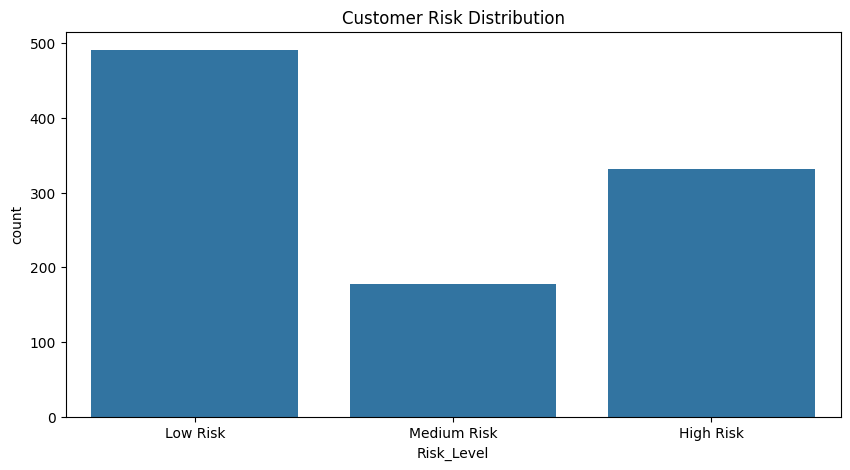

✅ Dashboard files exported successfully.


In [4]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Check if required files exist
required_files = ["churn_model.pkl", "feature_names.pkl", "clean_telco.csv"]
missing_files = [f for f in required_files if not os.path.exists(f)]

if missing_files:
    print(f"❌ Missing files: {missing_files}")
    print("Please ensure you have run the training notebook or uploaded these files.")
else:
    # 1. Load Model + Feature Schema
    model = pickle.load(open("churn_model.pkl", "rb"))
    feature_names = pickle.load(open("feature_names.pkl", "rb"))

    # 2. Load Dataset
    df = pd.read_csv("clean_telco.csv")

    # 3. Preprocessing
    df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
    df_encoded = pd.get_dummies(df, drop_first=True)

    for col in feature_names:
        if col not in df_encoded.columns:
            df_encoded[col] = 0
    df_encoded = df_encoded[feature_names]

    # 4. Predictions
    probs = model.predict_proba(df_encoded)[:, 1]
    df_results = df.copy()
    df_results["Churn_Probability"] = probs

    # 5. Risk Segmentation
    def risk_level(p):
        if p >= 0.8: return "High Risk"
        elif p >= 0.6: return "Medium Risk"
        else: return "Low Risk"

    def retention_action(p):
        if p >= 0.8: return "🔥 Call + 20% Discount"
        elif p >= 0.6: return "⚠️ Targeted SMS Offer"
        else: return "✅ No Immediate Action"

    df_results["Risk_Level"] = df_results["Churn_Probability"].apply(risk_level)
    df_results["Recommended_Action"] = df_results["Churn_Probability"].apply(retention_action)

    # 6. Revenue Impact
    ARPU = 500
    df_results["Revenue_At_Risk"] = df_results["Churn_Probability"] * ARPU
    total_revenue_risk = df_results["Revenue_At_Risk"].sum()
    print(f"💰 Total Revenue at Risk: {total_revenue_risk:,.2f} ETB")

    # 7. Summary
    summary = df_results.groupby("Risk_Level").agg({
        "Churn_Probability": "mean",
        "Revenue_At_Risk": "sum",
        "tenure": "mean",
        "MonthlyCharges": "mean"
    }).reset_index()

    # 8. Visualizations
    plt.figure(figsize=(10, 5))
    sns.countplot(x="Risk_Level", data=df_results, order=["Low Risk","Medium Risk","High Risk"])
    plt.title("Customer Risk Distribution")
    plt.show()

    # 9. Export
    df_results.to_csv("dashboard_data.csv", index=False)
    summary.to_csv("summary_data.csv", index=False)
    print("✅ Dashboard files exported successfully.")